In [1]:
import sys, os
import pickle
import anndata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
from IPython.display import Image
import pyro
import torch

data_type = 'float32'
os.environ["THEANO_FLAGS"] = f"device=cuda,floatX={data_type},force_device=True,dnn.enabled=False"

In [2]:
# --- CONFIG: change these to your paths ---
data_path = "/N/u/echimal/Quartz/Desktop/CLR_MRI/Human_GeoMx_Sep2025/"   # <-- base folder
spatial_h5ad = os.path.join(data_path, "CAA-AD_AnnData.h5ad")            # <-- GeoMx WTA spatial AnnData
results_root = os.path.join(data_path, "SpaceJam_results")               # where we'll save outputs
# Path where your inferred signatures are stored (according to "Regression.ipynb")
sig_dir = os.path.join(data_path, "Regression-model")
sig_files = {
    "AD+CAA": os.path.join(sig_dir, "AD+CAA_inferred_signatures.csv"),   # from previous notebook
    "Control": os.path.join(sig_dir, "Control_inferred_signatures.csv")
}
nucleus_count = os.path.join(data_path, "nuc_count.csv")            # <-- GeoMx WTA spatial nuclei count
# --- END CONFIG ---
os.makedirs(results_root, exist_ok=True)


In [3]:
# Import libraries (cell2location + spacejam)(SpaceJam needs to be installed in the conda environment and added to the kernel)
import cell2location
try:
    # try the helper runner used earlier (name may vary with versions)
    from cell2location.run_c2l import run_cell2location
except Exception:
    # fallback import path
    try:
        from cell2location import run_c2l
        run_cell2location = run_c2l.run_cell2location
    except Exception:
        run_cell2location = None

# import SpaceJam model class
import spacejam
from spacejam.models import LocationModelWTAMultiExperimentHierarchicalGeneLevel

print("cell2location version:", cell2location.__version__)
print("spacejam imported, using model:", LocationModelWTAMultiExperimentHierarchicalGeneLevel.__name__)

cell2location version: 0.1.5
spacejam imported, using model: spacejam.models.LocationModelWTAMultiExperimentHierarchicalGeneLevel


In [4]:
#Load Nanostring WTA data 
adata_wta = sc.read_h5ad(spatial_h5ad)
print("Loaded spatial AnnData:", adata_wta)

# Ensure layers/raw exist
if "counts" not in adata_wta.layers:
    # If X is raw counts, copy it to layers['counts']
    print("No layers['counts'] found — copying .X to layers['counts']")
    adata_wta.layers["counts"] = adata_wta.X.copy()


Loaded spatial AnnData: AnnData object with n_obs × n_vars = 190 × 18676
    obs: 'Scan Name', 'ROI', 'Segment (Name/ Label)', 'Segment Tags', 'Custom Segment Name', 'LOT_Human_NGS_Whole_Transcriptome_Atlas_RNA_1_0', 'ROI_ID', 'Scan_ID', 'disease_status', 'pathology', 'region'
    var: 'TargetName', 'ProbeID', 'Negative'
    obsm: 'negProbes'
No layers['counts'] found — copying .X to layers['counts']


/N/u/echimal/Quartz/.conda/envs/integration_env/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [5]:
#Add number of nuclei of the WTA
nuc = pd.read_csv(nucleus_count)
nuc = nuc.rename(columns={"Nuclei count": "nuclei_count"})
adata_wta.obs = adata_wta.obs.merge(
    nuc,
    on="ROI_ID",
    how="left"
)
print(adata_wta.obs[["ROI_ID", "nuclei_count"]].head())
print("Missing nuclei count:", adata_wta.obs["nuclei_count"].isna().sum())

       ROI_ID  nuclei_count
0      2534_A            73
1  2534_A 002            42
2  2534_A 003            23
3  2534_A 004            35
4  2534_A 005            86
Missing nuclei count: 0


In [6]:
print("Columns in obs:")
print(list(adata_wta.obs.columns))

# Try accessing the column directly
print("nuclei_count present?:", "nuclei_count" in adata_wta.obs.columns)

# Show first few values
print(adata_wta.obs["nuclei_count"].head())

Columns in obs:
['Scan Name', 'ROI', 'Segment (Name/ Label)', 'Segment Tags', 'Custom Segment Name', 'LOT_Human_NGS_Whole_Transcriptome_Atlas_RNA_1_0', 'ROI_ID', 'Scan_ID', 'disease_status', 'pathology', 'region', 'nuclei_count']
nuclei_count present?: True
0    73
1    42
2    23
3    35
4    86
Name: nuclei_count, dtype: int64


In [7]:
#Split WTA object by "Disease Status"
# Check unique values first
print(adata_wta.obs["disease_status"].unique())

# Split
adata_wta_ADCAA = adata_wta[adata_wta.obs["disease_status"] == "AD-CAA"].copy()
adata_wta_Control = adata_wta[adata_wta.obs["disease_status"] == "Control"].copy()

# Confirm sizes
print(adata_wta_ADCAA.shape)
print(adata_wta_Control.shape)


['AD-CAA', 'Control']
Categories (2, object): ['AD-CAA', 'Control']
(145, 18676)
(45, 18676)


/N/u/echimal/Quartz/.conda/envs/integration_env/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/N/u/echimal/Quartz/.conda/envs/integration_env/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [8]:
# -------- Prepare per-condition negative probes and nuclei counts --------
def prepare_counts(adata_subset):
    # Negative probes
    if "negProbes" in adata_subset.obsm:
        counts_neg = np.asarray(adata_subset.obsm["negProbes"])
        print("negProbes shape:", counts_neg.shape)
    else:
        print("Warning: adata_subset.obsm['negProbes'] not found. Using zeros.")
        counts_neg = np.zeros((adata_subset.n_obs, 0))  # empty

    # Nuclei counts
    nuc_key_candidates = ["AOINucleiCount", "nuclei_count", "n_nuclei", "nuclei"]
    counts_nuc = None
    for k in nuc_key_candidates:
        if k in adata_subset.obs.columns:
            counts_nuc = np.asarray(adata_subset.obs[k]).reshape(-1, 1)
            print("Using nuclei counts from obs['%s']" % k)
            break
    if counts_nuc is None:
        print("Warning: nuclei counts not found. Using ones.")
        counts_nuc = np.ones((adata_subset.n_obs, 1))

    return counts_neg, counts_nuc

# AD+CAA subset
counts_neg_ADCAA, counts_nuc_ADCAA = prepare_counts(adata_wta_ADCAA)

# Control subset
counts_neg_Control, counts_nuc_Control = prepare_counts(adata_wta_Control)


negProbes shape: (145, 139)
Using nuclei counts from obs['nuclei_count']
negProbes shape: (45, 139)
Using nuclei counts from obs['nuclei_count']


In [9]:
#totalCounts normalization used by some SpaceJam models
total_counts_per_spot = np.array(adata_wta.layers["counts"].sum(axis=1)).reshape(-1, 1)
print("Total counts per spot shape:", total_counts_per_spot.shape)

Total counts per spot shape: (190, 1)


In [10]:
import torch #This Part need top be run in a session with GPU Otherwise the next blocks will fail due to timeout
print(torch.cuda.is_available())  # Should return True
print(torch.cuda.device_count())  

True
1


In [11]:
print("AD+CAA:")
print("ROIs:", adata_wta_ADCAA.n_obs)
print("counts_nuc shape:", counts_nuc_ADCAA.shape)
print("counts_neg shape:", counts_neg_ADCAA.shape)

print("\nControl:")
print("ROIs:", adata_wta_Control.n_obs)
print("counts_nuc shape:", counts_nuc_Control.shape)
print("counts_neg shape:", counts_neg_Control.shape)    

AD+CAA:
ROIs: 145
counts_nuc shape: (145, 1)
counts_neg shape: (145, 139)

Control:
ROIs: 45
counts_nuc shape: (45, 1)
counts_neg shape: (45, 139)


In [12]:
#Load reference signatures
#Path to Regression results
rresults = '/N/u/echimal/Quartz/Desktop/CLR_MRI/Human_GeoMx_Sep2025/Regression-model/'
X_ref_ADCAA = pd.read_csv(
    f"{rresults}/AD+CAA_inferred_signatures.csv",
    index_col=0
)

X_ref_Control = pd.read_csv(
    f"{rresults}/Control_inferred_signatures.csv",
    index_col=0
)

In [13]:
#Intersection of Genes
def align_ref_and_spatial(X_ref, adata_wta):
    common = adata_wta.var_names.intersection(X_ref.index)
    print(f"Shared genes: {len(common)}")

    adata_sub = adata_wta[:, common].copy()
    X_ref_sub = X_ref.loc[common, :]

    return X_ref_sub, adata_sub


In [14]:
X_ref_ADCAA_sub, adata_wta_ADCAA_sub = align_ref_and_spatial(
    X_ref_ADCAA, adata_wta_ADCAA
)

X_ref_Control_sub, adata_wta_Control_sub = align_ref_and_spatial(
    X_ref_Control, adata_wta_Control
)


Shared genes: 14620
Shared genes: 14620


In [15]:
#Sanity Check
# AD+CAA
print(adata_wta_ADCAA_sub.n_obs, adata_wta_ADCAA_sub.n_vars)
print(X_ref_ADCAA_sub.shape)

# Control
print(adata_wta_Control_sub.n_obs, adata_wta_Control_sub.n_vars)
print(X_ref_Control_sub.shape)


145 14620
(14620, 46)
45 14620
(14620, 46)


In [16]:
from spacejam.models.LocationModelWTAMultiExperimentHierarchicalGeneLevel import LocationModelPyro

In [17]:
def make_spot2sample_mat(sample_ids):
    """
    sample_ids: array-like of length n_rois (e.g. Scan_ID)
    returns: n_rois x n_exper one-hot matrix
    """
    sample_cat = pd.Categorical(sample_ids)
    n_rois = len(sample_cat)
    n_exper = len(sample_cat.categories)

    mat = np.zeros((n_rois, n_exper), dtype=np.float32)
    mat[np.arange(n_rois), sample_cat.codes] = 1.0
    return mat, sample_cat.categories

In [18]:
# Build spot2sample matrix
spot2sample_ADCAA, exper_names_ADCAA = make_spot2sample_mat(
    adata_wta_ADCAA_sub.obs["Scan_ID"]
)

print("spot2sample shape:", spot2sample_ADCAA.shape)


spot2sample shape: (145, 4)


In [19]:
cell_number_prior = {
    "cells_per_spot": 8.0,
    "factors_per_spot": 7.0,
    "combs_per_spot": 2.5,
    "factors_per_combs": 3.0,     
    "cells_mean_var_ratio": 1.0,
    "factors_mean_var_ratio": 1.0,
    "combs_mean_var_ratio": 1.0,
}

In [20]:
#Model for AD+CAA
import torch
from spacejam.models import LocationModelWTAMultiExperimentHierarchicalGeneLevel as lm

print("Building spatial model: AD+CAA")

mod_ADCAA = lm.LocationModelPyro(
    X_ref_ADCAA_sub.values.astype(np.float32),   # genes x cell states
    adata_wta_ADCAA_sub.X.astype(np.float32),    # rois x genes
    counts_neg_ADCAA.astype(np.float32),         # rois x neg_probes
    spot2sample_ADCAA.astype(np.float32),        # rois x experiments
    cell_number_prior=cell_number_prior 
)

Building spatial model: AD+CAA


In [21]:
#LocationModelWTAMultiExperimentHierarchicalGeneLevel.py has to be fixed
#torch.tensors inside model() have to be forced to be dtype= self.dtype
#This was done because CUDA does not support Gamma sampling on integer tensors, float needed 

#Patterns like: dist.Gamma(...).to_event(1) were fixed to be able to handle batch-shaped priors 

#Numerical stabilization was added (either clapms or 1e-9)
#Without stabilization, probs = 1 -> to go undf
# shape <= 0 causes crashes 
#Logit replacement of NB 

#Otherwise it will fail

In [22]:
pyro.clear_param_store()
mod_ADCAA.model()

/N/u/echimal/Quartz/.conda/envs/integration_env/lib/python3.10/site-packages/pyro/primitives.py:163: RuntimeWarning: trying to observe a value outside of inference at data_target
  warnings.warn(


In [23]:
print("Training spatial model: AD+CAA")

loss_hist_ADCAA = mod_ADCAA.fit(
    n_steps=9000,
    lr=0.002
)


Training spatial model: AD+CAA
Step 0/9000 Loss = 9137612.4
Step 900/9000 Loss = 5053432.7
Step 1800/9000 Loss = 4573763.4
Step 2700/9000 Loss = 4438319.1
Step 3600/9000 Loss = 4390518.3
Step 4500/9000 Loss = 4365790.1
Step 5400/9000 Loss = 4352706.8
Step 6300/9000 Loss = 4345251.9
Step 7200/9000 Loss = 4340821.6
Step 8100/9000 Loss = 4338003.7


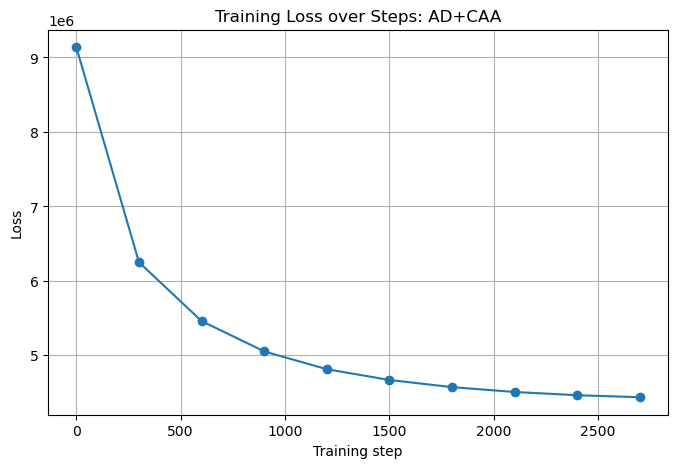

In [25]:
steps = list(range(0, 3000, 300))  # 0, 300, 600, ..., 2700
losses = [
    9137612.4, 5053432.7, 4573763.4, 4438319.1, 4390518.3,
    4365790.1, 4352706.8, 4345251.9, 4340821.6, 4338003.7
]

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(steps, losses, marker='o')
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("Training Loss over Steps: AD+CAA")
plt.grid(True)
plt.show()



In [25]:
#Save ADCAA model (Trained parameters)
param_store = pyro.get_param_store()

cpu_state = {
    name: value.detach().cpu()
    for name, value in param_store.items()
}

torch.save(cpu_state, "ADCAA_param_store.pt")


In [ ]:
#Reload Trained paramenters
#import pyro
#import torch

#pyro.clear_param_store()

# Rebuild model object FIRST
#mod_ADCAA = lm.LocationModelPyro(
#    X_ref_ADCAA_sub.values.astype(np.float32),
#    adata_wta_ADCAA_sub.X.astype(np.float32),
#    counts_neg_ADCAA.astype(np.float32),
#    spot2sample_ADCAA.astype(np.float32),
#    cell_number_prior=cell_number_prior
#)

# Load parameters
#state = torch.load("ADCAA_param_store.pt", map_location="cpu")
#pyro.get_param_store().set_state(state)


In [27]:
#Extract posterior means
posterior_means = {}

for name, param in pyro.get_param_store().items():
    if name.endswith("_loc"):  # mean of variational distribution
        posterior_means[name.replace("_loc", "")] = param.detach().cpu()

torch.save(posterior_means, "ADCAA_variational_means.pt")



In [28]:
#Clear CUDA / hyperparameters to avoid leakage
import  gc
pyro.clear_param_store()
gc.collect()
torch.cuda.empty_cache()


In [32]:
# Build spot2sample matrix for control 
spot2sample_Control, exper_names_Control = make_spot2sample_mat(
    adata_wta_Control_sub.obs["Scan_ID"]
)

print("spot2sample shape:", spot2sample_Control.shape)

spot2sample shape: (45, 3)


In [33]:
#Model for Control
from spacejam.models import LocationModelWTAMultiExperimentHierarchicalGeneLevel as lm

print("Building spatial model: Control")
mod_CTRL = lm.LocationModelPyro(
    X_ref_Control_sub.values.astype(np.float32),   # genes x cell states
    adata_wta_Control_sub.X.astype(np.float32),    # rois x genes
    counts_neg_Control.astype(np.float32),         # rois x neg_probes
    spot2sample_Control.astype(np.float32),        # rois x experiments
    cell_number_prior=cell_number_prior 
)

Building spatial model: Control


In [36]:
print("Training spatial model: Control")

loss_hist_Control = mod_CTRL.fit(
    n_steps=9000,
    lr=0.002
)

Training spatial model: Control
Step 0/9000 Loss = 2890096.4
Step 900/9000 Loss = 1590501.4
Step 1800/9000 Loss = 1420950.4
Step 2700/9000 Loss = 1365494.9
Step 3600/9000 Loss = 1343108.6
Step 4500/9000 Loss = 1332919.6
Step 5400/9000 Loss = 1326601.7
Step 6300/9000 Loss = 1322941.2
Step 7200/9000 Loss = 1320872.8
Step 8100/9000 Loss = 1319776.6


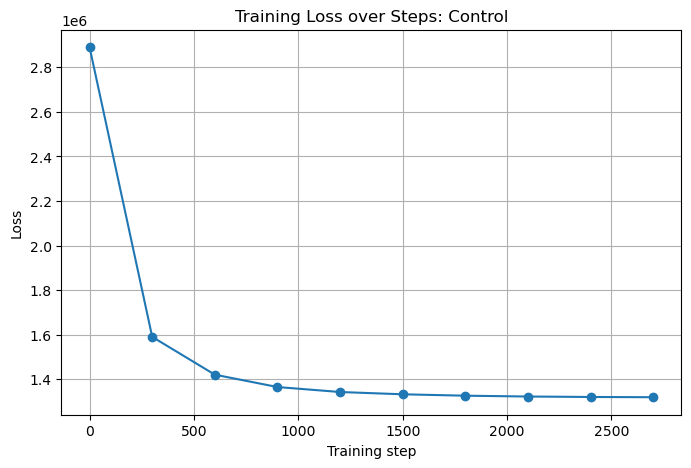

In [37]:
steps = list(range(0, 3000, 300))  # 0, 300, 600, ..., 2700
losses = [
    2890096.4, 1590501.4, 1420950.4, 1365494.9, 1343108.6,
    1332919.6, 1326601.7, 1322941.2, 1320872.8, 1319776.6
]

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(steps, losses, marker='o')
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("Training Loss over Steps: Control")
plt.grid(True)
plt.show()


In [38]:
#Save Control model (Trained parameters)
param_store = pyro.get_param_store()

cpu_state = {
    name: value.detach().cpu()
    for name, value in param_store.items()
}

torch.save(cpu_state, "CTRL_param_store.pt")

#Extract posterior means
posterior_means = {}

for name, param in pyro.get_param_store().items():
    if name.endswith("_loc"):  # mean of variational distribution
        posterior_means[name.replace("_loc", "")] = param.detach().cpu()

torch.save(posterior_means, "CTRL_variational_means.pt")

In [ ]:
#Reload Trained paramenters
#import pyro
#import torch

#pyro.clear_param_store()

# Rebuild model object FIRST
#mod_CTRL = lm.LocationModelPyro(
#    X_ref_Control_sub.values.astype(np.float32),
#    adata_wta_Control_sub.X.astype(np.float32),
#    counts_neg_Control.astype(np.float32),
#    spot2sample_Control.astype(np.float32),
#    cell_number_prior=cell_number_prior
#)

# Load parameters
#state = torch.load("CTRL_param_store.pt", map_location="cpu")
#pyro.get_param_store().set_state(state)

In [39]:
import sys
for module in sys.modules:
    try:
        print(module,sys.modules[module].__version__)
    except:
        try:
            if  type(sys.modules[module].version) is str:
                print(module,sys.modules[module].version)
            else:
                print(module,sys.modules[module].version())
        except:
            try:
                print(module,sys.modules[module].VERSION)
            except:
                pass

sys 3.10.19 | packaged by conda-forge | (main, Oct 22 2025, 22:29:10) [GCC 14.3.0]
re 2.2.1
ipaddress 1.0
ipykernel._version 7.1.0
json 2.0.9
jupyter_client._version 8.6.3
platform 1.0.8
zmq.sugar.version 27.1.0
zmq.sugar 27.1.0
zmq 27.1.0
logging 0.5.1.2
traitlets._version 5.14.3
traitlets 5.14.3
jupyter_core.version 5.9.1
jupyter_core 5.9.1
tornado 6.5.2
zlib 1.0
_ctypes 1.1.0
ctypes 1.1.0
colorama 0.4.6
_curses b'2.2'
socketserver 0.4
argparse 1.1
dateutil._version 2.9.0.post0
dateutil 2.9.0.post0
six 1.17.0
_decimal 1.70
decimal 1.70
platformdirs.version 4.5.0
platformdirs 4.5.0
_csv 1.0
csv 1.0
jupyter_client 8.6.3
ipykernel 7.1.0
IPython.core.release 8.37.0
executing.version 2.2.1
executing 2.2.1
pure_eval.version 0.2.3
pure_eval 0.2.3
stack_data.version 0.6.3
stack_data 0.6.3
pygments 2.19.2
IPython.core.crashhandler 8.37.0
pickleshare 0.7.5
decorator 5.2.1
_sqlite3 2.6.0
sqlite3.dbapi2 2.6.0
sqlite3 2.6.0
exceptiongroup._version 1.3.0
exceptiongroup 1.3.0
wcwidth 0.2.14
prompt_

/tmp/ipykernel_647332/1799866556.py:4: DeprecationWarning: numpy.core is deprecated and has been renamed to numpy._core. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.__version__.
  print(module,sys.modules[module].__version__)
/tmp/ipykernel_647332/1799866556.py:4: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(module,sys.modules[module].__version__)
